In [1]:
import pandas as pd

In [32]:
from google.colab import files
files.upload()

Saving hospital3.csv to hospital3.csv


{'hospital3.csv': b"Patient Id,Appointment Date,Appointment Time,Doctor Name,Gender,Age,Department,Admission Status,Appointment Status,Wait time,Delay,Check-in Time,Consultation Start Time,Consultation End Time,Consultation Duration,Bed Number,Total Bill,Emergency Cases,Satisfaction,Appointment Delay,Bed Utilization,Department Load,Waiting Category\r\n780-96-6113,09-09-2024,9:25:00 AM,W. Breede,Female,63,Orthopedics,Not Admission,Not Completed,32,7,13:46,13:46,14:01,15,303,3327,No,4,7,Not Occupied,2340,Long\r\n714-35-6722,09-09-2024,4:42:00 PM,Y. Baldetti,Male,31,Neurology,Not Admission,Not Completed,22,20,13:48,13:48,14:09,21,303,4024,No,5,20,Not Occupied,1816,Long\r\n571-85-3714,09-09-2024,12:14:00 AM,M. Semerad,Male,75,Renal,Not Admission,Not Completed,16,29,08:00,08:00,08:15,15,326,699,No,3,29,Not Occupied,1314,Medium\r\n404-43-9499,09-09-2024,8:33:00 PM,K. Blaydes,Male,79,Gastroenterology,Admission,Completed,38,15,11:40,11:54,12:30,36,183,21960,No,5,15,Occupied,1859,Long\r\n552-51

In [33]:
df=pd.read_csv("hospital3.csv")

In [34]:
# 1. Dataset dimensions
print("Dataset Shape:", df.shape)

# 2. Column names
print("\nColumns:")
print(df.columns.tolist())

# 3. Data types and non-null values
print("\nDataset Info:")
df.info()

# 4. First 5 rows
print("\nFirst 5 Rows:")
print(df.head())

# 5. Summary statistics for numerical columns
print("\nNumerical Summary:")
print(df.describe())

# 6. Summary for categorical columns
print("\nCategorical Summary:")
print(df.describe(include='object'))

# 7. Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (9216, 23)

Columns:
['Patient Id', 'Appointment Date', 'Appointment Time', 'Doctor Name', 'Gender', 'Age', 'Department', 'Admission Status', 'Appointment Status', 'Wait time', 'Delay', 'Check-in Time', 'Consultation Start Time', 'Consultation End Time', 'Consultation Duration', 'Bed Number', 'Total Bill', 'Emergency Cases', 'Satisfaction', 'Appointment Delay', 'Bed Utilization', 'Department Load', 'Waiting Category']

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9216 entries, 0 to 9215
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Patient Id               9216 non-null   object
 1   Appointment Date         9216 non-null   object
 2   Appointment Time         9216 non-null   object
 3   Doctor Name              9216 non-null   object
 4   Gender                   9216 non-null   object
 5   Age                      9216 non-null   int64 
 6   Department  

In [27]:
# Check missing values
print("Missing values before handling:")
print(df.isnull().sum())

# Fill missing values based on data type
for col in df.columns:
    if df[col].dtype == "object":
        # Fill categorical columns with mode (most frequent value)
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        # Fill numerical columns with median
        df[col].fillna(df[col].median(), inplace=True)

# Verify missing values are removed
print("\nMissing values after handling:")
print(df.isnull().sum())

Missing values before handling:
Patient Id                 0
Appointment Date           0
Appointment Time           0
Doctor Name                0
Gender                     0
Age                        0
Department                 0
Admission Status           0
Appointment Status         0
Wait time                  0
Delay                      0
Check-in Time              0
Consultation Start Time    0
Consultation End Time      0
Consultation Duration      0
Bed Number                 0
Total Bill                 0
Emergency Cases            0
Satisfaction               0
dtype: int64

Missing values after handling:
Patient Id                 0
Appointment Date           0
Appointment Time           0
Doctor Name                0
Gender                     0
Age                        0
Department                 0
Admission Status           0
Appointment Status         0
Wait time                  0
Delay                      0
Check-in Time              0
Consultation Start Time 

/tmp/ipykernel_975/1051403653.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
/tmp/ipykernel_975/1051403653.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

In [28]:
print("Duplicate rows before removing:", df.duplicated().sum())

Duplicate rows before removing: 0


In [29]:
print("Dataset Shape:", df.shape)

Dataset Shape: (9216, 19)


In [30]:
import pandas as pd

df["Appointment Date"] = pd.to_datetime(
    df["Appointment Date"], errors="coerce"
)

# Convert time columns
time_columns = [
    "Appointment Time",
    "Check-in Time",
    "Consultation Start Time",
    "Consultation End Time"
]

for col in time_columns:
    df[col] = pd.to_datetime(
        df[col], format="%H:%M", errors="coerce"
    ).dt.time

# Check data types
print(df.dtypes)

Patient Id                         object
Appointment Date           datetime64[ns]
Appointment Time           datetime64[ns]
Doctor Name                        object
Gender                             object
Age                                 int64
Department                         object
Admission Status                   object
Appointment Status                 object
Wait time                           int64
Delay                               int64
Check-in Time                      object
Consultation Start Time            object
Consultation End Time              object
Consultation Duration               int64
Bed Number                          int64
Total Bill                          int64
Emergency Cases                    object
Satisfaction                        int64
dtype: object


In [31]:
# ------------------------------------
# 1. Appointment Delay
# ------------------------------------
df["Appointment Delay"] = df["Delay"]

# ------------------------------------
# 2. Bed Utilization
# ------------------------------------
df["Bed Utilization"] = df["Admission Status"].apply(
    lambda x: "Occupied" if x == "Admission" else "Not Occupied"
)

# ------------------------------------
# 3. Department Load
# ------------------------------------
dept_load = df["Department"].value_counts()

df["Department Load"] = df["Department"].map(dept_load)

# ------------------------------------
# 4. Waiting Categories
# ------------------------------------
def waiting_category(wait):
    if wait <= 10:
        return "Short"
    elif wait <= 20:
        return "Medium"
    else:
        return "Long"

df["Waiting Category"] = df["Wait time"].apply(waiting_category)

# ------------------------------------
# Display
# ------------------------------------
print(df[[
    "Delay",
    "Appointment Delay",
    "Bed Utilization",
    "Department",
    "Department Load",
    "Wait time",
    "Waiting Category"
]].head())

   Delay  Appointment Delay Bed Utilization        Department  \
0      7                  7    Not Occupied       Orthopedics   
1     20                 20    Not Occupied         Neurology   
2     29                 29    Not Occupied             Renal   
3     15                 15        Occupied  Gastroenterology   
4     11                 11        Occupied     Physiotherapy   

   Department Load  Wait time Waiting Category  
0             2340         32             Long  
1             1816         22             Long  
2             1314         16           Medium  
3             1859         38             Long  
4             1887         36             Long  


In [36]:
import pandas as pd

# ==========================
# Healthcare Operational KPIs
# ==========================

# 1. Total Patients
total_patients = df["Patient Id"].nunique()

# 2. Average Waiting Time
avg_waiting_time = df["Wait time"].mean()

# 3. Bed Utilization Rate (%)
bed_utilization_rate = (
    (df["Admission Status"] == "Admission").sum()
    / len(df)
) * 100

# 4. Patient Satisfaction Score
patient_satisfaction_score = df["Satisfaction"].mean()

# 5. Appointment Delay (%)
appointment_delay_percent = (
    (df["Delay"] > 0).sum()
    / len(df)
) * 100

# 6. Emergency Cases
emergency_cases = (
    df["Emergency Cases"] == "Yes"
).sum()

# 7. Department Performance
department_performance = df.groupby("Department").agg({
    "Patient Id": "count",
    "Wait time": "mean",
    "Satisfaction": "mean",
    "Total Bill": "sum"
}).rename(columns={
    "Patient Id": "Total Patients",
    "Wait time": "Avg Waiting Time",
    "Satisfaction": "Avg Satisfaction",
    "Total Bill": "Revenue"
})

# 8. Revenue Generated
revenue_generated = df["Total Bill"].sum()

# ==========================
# Display KPIs
# ==========================

print("===== SMART HOSPITAL KPIs =====")
print(f"Total Patients           : {total_patients}")
print(f"Average Waiting Time     : {avg_waiting_time:.2f} minutes")
print(f"Bed Utilization Rate     : {bed_utilization_rate:.2f}%")
print(f"Patient Satisfaction     : {patient_satisfaction_score:.2f}/5")
print(f"Appointment Delay        : {appointment_delay_percent:.2f}%")
print(f"Emergency Cases          : {emergency_cases}")
print(f"Revenue Generated        : ₹{revenue_generated:,.2f}")

print("\n===== Department Performance =====")
print(department_performance)

===== SMART HOSPITAL KPIs =====
Total Patients           : 9216
Average Waiting Time     : 35.26 minutes
Bed Utilization Rate     : 50.04%
Patient Satisfaction     : 2.99/5
Appointment Delay        : 100.00%
Emergency Cases          : 1405
Revenue Generated        : ₹274,235,610.00

===== Department Performance =====
                  Total Patients  Avg Waiting Time  Avg Satisfaction   Revenue
Department                                                                    
Gastroenterology            1859         35.440559          2.991393  52474125
Neurology                   1816         35.431167          2.952643  53807652
Orthopedics                 2340         35.027778          2.982051  71370024
Physiotherapy               1887         35.317435          3.065183  58255786
Renal                       1314         35.098174          2.958904  38328023


In [37]:
#Analytics Investigation
department_wait = df.groupby("Department")["Wait time"].mean().sort_values(ascending=False)

print(department_wait)

Department
Gastroenterology    35.440559
Neurology           35.431167
Physiotherapy       35.317435
Renal               35.098174
Orthopedics         35.027778
Name: Wait time, dtype: float64


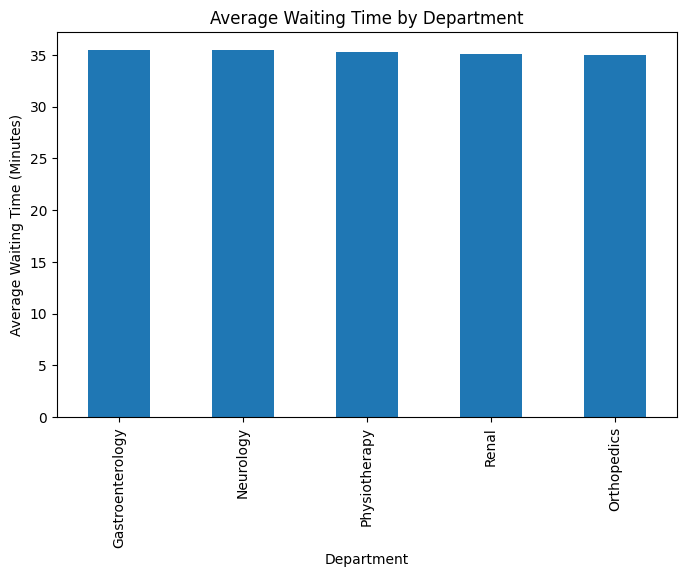

In [38]:
import matplotlib.pyplot as plt

department_wait.plot(kind="bar", figsize=(8,5))
plt.title("Average Waiting Time by Department")
plt.xlabel("Department")
plt.ylabel("Average Waiting Time (Minutes)")
plt.show()

Doctor Name
H. Kehoe        2
W. Keyworth     2
P. Lotte        2
U. Bulfield     2
Q. Simon        2
               ..
I. Moen         1
I. Monelle      1
I. Morsley      1
I. Moulster     1
I. McClounan    1
Name: Patient Id, Length: 9185, dtype: int64


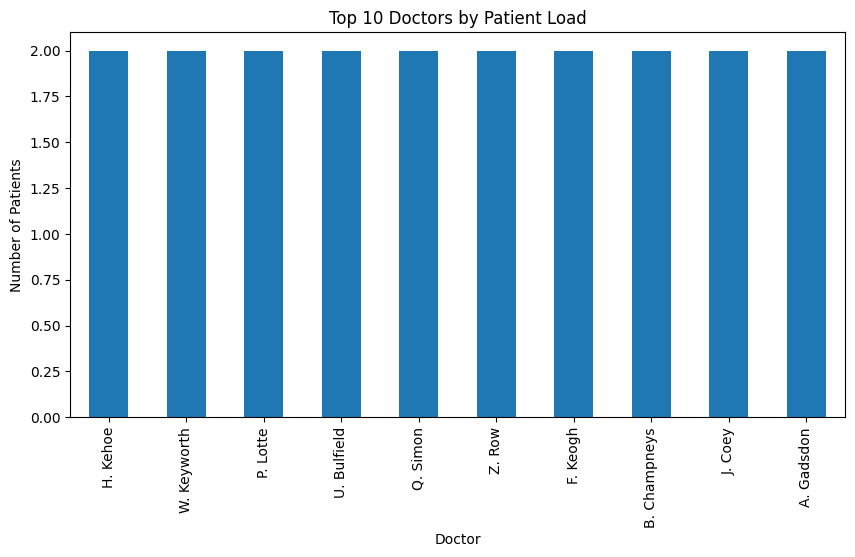

In [39]:
#Doctor vs Patient Load
doctor_load = df.groupby("Doctor Name")["Patient Id"].count().sort_values(ascending=False)

print(doctor_load)
doctor_load.head(10).plot(kind="bar", figsize=(10,5))
plt.title("Top 10 Doctors by Patient Load")
plt.xlabel("Doctor")
plt.ylabel("Number of Patients")
plt.show()

Emergency Cases
No     15.687748
Yes    15.969395
Name: Delay, dtype: float64


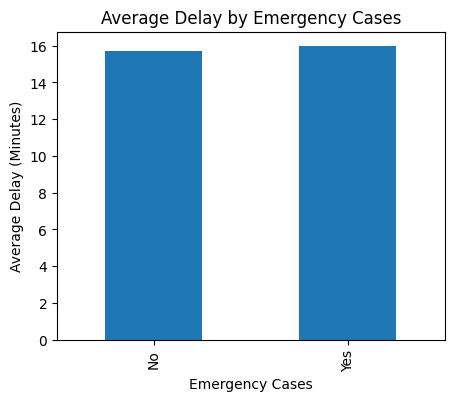

In [40]:
#Emergency Cases vs Delays
emergency_delay = df.groupby("Emergency Cases")["Delay"].mean()

print(emergency_delay)
emergency_delay.plot(kind="bar", figsize=(5,4))
plt.title("Average Delay by Emergency Cases")
plt.xlabel("Emergency Cases")
plt.ylabel("Average Delay (Minutes)")
plt.show()

Satisfaction
1    34.937935
2    35.069259
3    35.201011
4    35.681719
5    35.415991
Name: Wait time, dtype: float64


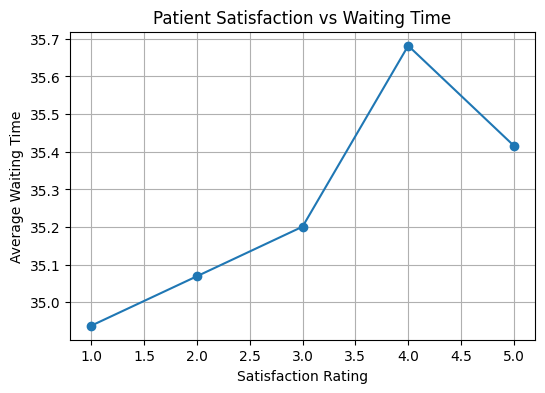

In [41]:
#Patient Satisfaction vs Waiting Time
satisfaction_wait = df.groupby("Satisfaction")["Wait time"].mean()

print(satisfaction_wait)
satisfaction_wait.plot(marker='o', figsize=(6,4))
plt.title("Patient Satisfaction vs Waiting Time")
plt.xlabel("Satisfaction Rating")
plt.ylabel("Average Waiting Time")
plt.grid(True)
plt.show()

In [42]:
#Bed Utilization Trends
bed_utilization = df["Bed Utilization"].value_counts()

print(bed_utilization)

Bed Utilization
Occupied        4612
Not Occupied    4604
Name: count, dtype: int64


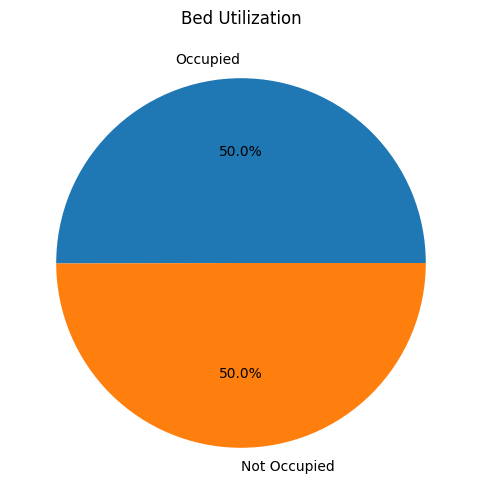

In [43]:
bed_utilization.plot(kind="pie", autopct="%1.1f%%", figsize=(6,6))
plt.ylabel("")
plt.title("Bed Utilization")
plt.show()

In [45]:
#Dashboard Development
import pandas as pd

# ==========================
# Executive Overview
# ==========================

# Total Patients
total_patients = df["Patient Id"].nunique()

# Revenue
revenue = df["Total Bill"].sum()

# Average Satisfaction
avg_satisfaction = df["Satisfaction"].mean()

# Average Waiting Time
avg_waiting = df["Wait time"].mean()

print("========= Executive Overview =========")
print(f"Total Patients      : {total_patients}")
print(f"Revenue             : ₹{revenue:,.2f}")
print(f"Average Satisfaction: {avg_satisfaction:.2f}")
print(f"Average Waiting Time: {avg_waiting:.2f} minutes")

# ==========================
# Waiting Trend
# ==========================

waiting_trend = (
    df.groupby("Appointment Date")["Wait time"]
      .mean()
      .reset_index()
)

# ==========================
# Patient Admissions
# ==========================

patient_admissions = (
    df["Admission Status"]
      .value_counts()
      .reset_index()
)

patient_admissions.columns = ["Admission Status", "Patients"]

# ==========================
# Department Activity
# ==========================

department_activity = (
    df.groupby("Department")["Patient Id"]
      .count()
      .reset_index()
)

department_activity.columns = ["Department", "Patients"]

# ==========================
# Peak Hour Load
# ==========================

# Automatically detects both AM/PM and 24-hour formats
df["Appointment Hour"] = pd.to_datetime(
    df["Appointment Time"],
    errors="coerce"
).dt.hour

peak_hour = (
    df.groupby("Appointment Hour")["Patient Id"]
      .count()
      .reset_index()
)

peak_hour.columns = ["Hour", "Patients"]

# ==========================
# Doctor Utilization
# ==========================

doctor_utilization = (
    df.groupby("Doctor Name")["Patient Id"]
      .count()
      .reset_index()
)

doctor_utilization.columns = ["Doctor Name", "Patients"]

# ==========================
# Appointment Delays
# ==========================

appointment_delays = (
    df.groupby("Department")["Delay"]
      .mean()
      .reset_index()
)

appointment_delays.columns = ["Department", "Average Delay"]

# ==========================
# Bed Occupancy
# ==========================

bed_occupancy = (
    df["Bed Utilization"]
      .value_counts()
      .reset_index()
)

bed_occupancy.columns = ["Bed Utilization", "Patients"]

# ==========================
# Satisfaction Trend
# ==========================

satisfaction_trend = (
    df.groupby("Appointment Date")["Satisfaction"]
      .mean()
      .reset_index()
)

# ==========================
# Waiting Time Impact
# ==========================

waiting_impact = (
    df.groupby("Waiting Category")
      .agg({
          "Wait time": "mean",
          "Satisfaction": "mean"
      })
      .reset_index()
)

# ==========================
# Service Quality
# ==========================

service_quality = (
    df.groupby("Department")["Satisfaction"]
      .mean()
      .reset_index()
)

service_quality.columns = ["Department", "Average Satisfaction"]

# ==========================
# Save All Summary Tables
# ==========================

waiting_trend.to_csv("waiting_trend.csv", index=False)
patient_admissions.to_csv("patient_admissions.csv", index=False)
department_activity.to_csv("department_activity.csv", index=False)
peak_hour.to_csv("peak_hour.csv", index=False)
doctor_utilization.to_csv("doctor_utilization.csv", index=False)
appointment_delays.to_csv("appointment_delays.csv", index=False)
bed_occupancy.to_csv("bed_occupancy.csv", index=False)
satisfaction_trend.to_csv("satisfaction_trend.csv", index=False)
waiting_impact.to_csv("waiting_impact.csv", index=False)
service_quality.to_csv("service_quality.csv", index=False)

print("\nAll dashboard summary tables created successfully!")

========= Executive Overview =========
Total Patients      : 9216
Revenue             : ₹274,235,610.00
Average Satisfaction: 2.99
Average Waiting Time: 35.26 minutes


/tmp/ipykernel_975/1120960444.py:65: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Appointment Hour"] = pd.to_datetime(



All dashboard summary tables created successfully!
